### Supervisor 에이전트 시스템의 구조
어떤 작업을 직접 수행하는게 아닌, 어떤 에이전트를 골라야할지 직접 판단하는 역할이다.
1. suvervisor 에이전트 시스템에서 하나의 supervisor 에이전트가 작업 수행을 위해 하위 에이전트 명령을 하달한다.
2. 하위 에이전트들은 작업 명령을 받으면, 수행 결과를 supervisor에 전달하고, 이결과를 반복한다.

- Hierarchical(계층적) 구조도 이와같은 형식으로 동작한다.

![scrennsh](./image/image.png)

- 복잡한 작업에대해서, supervisor에게 자율성을 부여하고, 관리를한다. supervisor가 판단하기에 노드호출하고, 사용자의 질문을 처리해주는 개념이다.

- 여러개의 agent를 효과적으로 관리하는 방법이다.

### 주식 분석 supervisor 에이전트 시스템의 구조

주신 분석 supervisor 에이전트 시스템에서는 supervisor가 하위 에이전트들과 주식 분석 관련 Task를 수행한다.

하위 에이전트로는 `Researcher`, `Stock Analyzer`, `Chart Generator`가 있으며, 이들을 `Router(라우터)`를 활용해 복잡한 명령을 수행한다.

에이전트들은 특별히 어떤부분만 바뀌어야 할 부분이 있다면, create_react_agent를 사용하여 구축을 할 수 있다. 이것으로 어떤 llm을 쓸지, 어떤 tool을 사용할지 하나의 함수안에 넣어줘서 쉽게 구축할 수 있다.

Supervisor 에이전트는 routeResponse기반의 structured_output을 통해 다음 작업을 수행할 에이전트를 선택한다.

In [1]:
# pip install yfinance

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

### 웹 검색과 코드 실행 도구 정의

In [3]:
from typing import Annotated
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_experimental.tools import PythonREPLTool

tavily_tool = TavilySearchResults(max_results=5)
python_repl_tool = PythonREPLTool()

### yfinance로 주어진 주식 종목에 대한 최근 주가 및 재무 분석 도구 정의

In [4]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

ticker = yf.Ticker("NVDA")
historical_prices = ticker.history(period="5d", interval="1d")

last_5_days_close = historical_prices["Close"].tail(5) # 종가정보
last_5_days_close_dict = {date.strftime("%Y-%m-%d"): price for date, price in last_5_days_close.items()} # 딕셔너리 형태로 가져온다

last_5_days_close_dict

{'2024-11-01': 135.39999389648438,
 '2024-11-04': 136.0500030517578,
 '2024-11-05': 139.91000366210938,
 '2024-11-06': 145.61000061035156,
 '2024-11-07': 148.8800048828125}

In [5]:
ticker.get_financials()

,2024-01-31,2023-01-31,2022-01-31,2021-01-31
TaxEffectOfUnusualItems,0.0,-284130000.0,0.0,0.0
TaxRateForCalcs,0.12,0.21,0.019,0.017
NormalizedEBITDA,35583000000.0,7340000000.0,11351000000.0,5691000000.0
TotalUnusualItems,0.0,-1353000000.0,0.0,0.0
TotalUnusualItemsExcludingGoodwill,0.0,-1353000000.0,0.0,0.0
NetIncomeFromContinuingOperationNetMinorityInterest,29760000000.0,4368000000.0,9752000000.0,4332000000.0
ReconciledDepreciation,1508000000.0,1544000000.0,1174000000.0,1098000000.0
ReconciledCostOfRevenue,16621000000.0,11618000000.0,9439000000.0,6279000000.0
EBITDA,35583000000.0,5987000000.0,11351000000.0,5691000000.0
EBIT,34075000000.0,4443000000.0,10177000000.0,4593000000.0


In [6]:
from langchain.tools import BaseTool, StructuredTool, tool

# 재무 분석 툴 설정
@tool
def stock_analysis(ticker:str) -> str:
    """
    주어진 주식 티커에 대한 업데이트된 종합적인 재무 분석을 수행합니다.
    최신 주가 정보, 재무 지표, 성장률, 밸류에이션 및 주요 비율을 제공합니다.
    가장 최근 영업일 기준의 데이터를 사용합니다.
    
    :param ticker: 분석할 주식의 티커 심볼
    :return: 재무 분석 결과를 포함한 문자열
    """
    # 숫자 자리수를 나타내는 formatting
    def format_number(number):
        if number is None or pd.isna(number):
            return "N/A"
        return f"{number:,.0f}" # 소수점업이 반올림
    
    # yfinance를 통해 가져올수 있는 여러가지 재무정보를 정리해서 나타내는 재무정보 helper함수.
    def format_financial_summary(financials): 
        summary = {}
        for date, data in financials.items():
            date_str = date.strftime("%Y-%m-%d")
            summary[date_str] = {
                "총수익": format_number(data.get('TotalRevenue')),
                "영업이익": format_number(data.get('OperatingIncome')),
                "순이익": format_number(data.get('NetIncome')),
                "EBITDA": format_number(data.get('EBITDA')),
                "EPS(희석)": f"${data.get('DilutedEPS'):.2f}" if pd.notna(data.get('DilutedEPS')) else "N/A"
            }
        return summary
    
    # 주가정복 가져오기
    ticker = yf.Ticker(ticker)
    historical_prices = ticker.history(period='5d', interval='1d')
    last_5_days_close = historical_prices['Close'].tail(5)
    last_5_days_close_dict = {date.strftime('%Y-%m-%d'): price for date, price in last_5_days_close.items()}
    # 연간 및 분기별 재무제표 데이터 가져오기
    annual_financials = ticker.get_financials() # 재무재표정리. (년간)
    quarterly_financials = ticker.get_financials(freq="quarterly") # 분기별 재무재표
    
    return str({
        "최근 5일간 종가": last_5_days_close_dict,
        "연간 재무제표 요약": format_financial_summary(annual_financials),
        "분기별 재무제표 요약": format_financial_summary(quarterly_financials),
    })


### Supervisor 에이전트 정의

In [7]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI
from pydantic import BaseModel
from typing import Literal

#member를 넣어주고, 이것을 system_prompt에 넣어준다.
members = ["Researcher", "Stock_Analyzer", "Chart_Generator"] # 하위 agent들

system_prompt = (
    "You are a supervisor tasked with managing a conversation between the"
    " following workers: {members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH."
)
# Our team supervisor is an LLM node. It just picks the next agent to process
# and decides when the work is completed
# system_prompt에서 끝낼꺼면 FINISH로 끝내라고 지정을 했다.
options = ["FINISH"] + members

# options의 값중 하나만 받기위해 *를 넣어준다. 리스트의 각 요소로 분리해주는 역할이다.
class routeResponse(BaseModel):
    next: Literal[*options]

# Agent가 무엇일지 정해준다. options에다가 FINISH까지 넣어줬으므로, 끝내려면 FINISH도 넣어준다.
# partial은 prompt template의 부분적인 매개변수 역할을 해준다. 
prompt = ChatPromptTemplate(
    [
        ("system", system_prompt),
        MessagesPlaceholder(variable_name="messages"),
        (
            "system",
            "Given the conversation above, who should act next?"
            " Or shuld we FINISH? Select one of: {options}",
        )
    ]
).partial(options=str(options), members=", ".join(members))

llm = ChatOpenAI(model="gpt-4o-mini")

def supervisor_agent(state):
    supervisor_chain = (
        prompt | llm.with_structured_output(routeResponse)
    )
    return supervisor_chain.invoke(state)

### 하위 에이전트 정의 함수
하위 에이전트가 어떤 작업을 해야할지 에대해서 정의.

In [8]:
from langchain_core.messages import HumanMessage

def agent_node(state, agent, name):
    result = agent.invoke(state)
    return {"messages": [HumanMessage(content=result["messages"][-1].content, name=name)]}

### 하위 에이전트, 노드, 엣지 정의
에이전트를 노드로 만들어주기.

In [ ]:
import functools
import operator
from typing import Sequence, TypedDict

from langchain_core.messages import BaseMessage

from langgraph.graph import END, START, StateGraph, add_messages
from langgraph.prebuilt import create_react_agent

class AgentState(TypedDict):
    
    messages: Annotated[Sequence[BaseMessage], operator.add]
    # messages: Annotated[Sequence[BaseMessage], add_messages]
    next: str

research_system_prompt = """You are a helpful research analyst who is specialized in 
gathering valuable info for given stock."""

research_agent = create_react_agent(llm, tools=[tavily_tool], state_modifier=research_system_prompt)
research_node = functools.partial(agent_node, agent=research_agent, name="Researcher")


# NOTE: This perfomms Arbitrary code execution. proceed with caution.
stock_system_prompt = """You are a helpful Stock and fianancial analyst. Never hallucinate the given metric."""
stock_agent = create_react_agent(llm, tools=[stock_analysis], state_modifier=stock_system_prompt)
stock_node = functools.partial(agent_node, agent=stock_agent, name="Stock_Analyzer")

# NOTE: This perfomms Arbitrary code execution. proceed with caution.
chart_system_prompt="""You are a helpful Stock Chart Generator. 
Only make accurate charts for given query. Chart design and accuracy should be state of the art.
Never make any other mention."""
chart_agent = create_react_agent(llm, tools=[python_repl_tool], state_modifier=chart_system_prompt)
chart_node = functools.partial(agent_node, agent=chart_agent, name="Chart_Generator")

# node
workflow = StateGraph(AgentState)
workflow.add_node("Researcher", research_node)
workflow.add_node("Stock_Analyzer", stock_node)
workflow.add_node("Chart_Generator", chart_node)
workflow.add_node("supervisor", supervisor_agent)

# edge
# members = ["Researcher", "Stock_Analyzer", "Chart_Generator"] 이 모든 agent들은 supervisor들에게 결과를 보낸다.
for member in members:
    workflow.add_edge(member, "supervisor")

conditional_map = {k: k for k in members} # members의 모든 agent들에 대해서 그 이름과 노드를 딕셔너리로(key와 value쌍으로) 만들어준다.
conditional_map["FINISH"] = END
workflow.add_conditional_edges(
    "supervisor",
    lambda x: x["next"], # 다음에 어떤 agent들이 작동할지 값을 가지고있다.
    conditional_map
)

workflow.add_edge(START, "supervisor")

graph = workflow.compile()

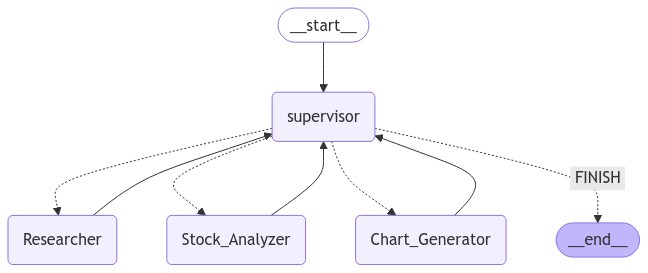

In [10]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

{'supervisor': {'next': 'Researcher'}}
-----
{'Researcher': {'messages': [HumanMessage(content='애플(AAPL) 주식에 대한 최근 정보를 바탕으로 구매 의사 결정을 돕겠습니다.\n\n1. **주가 예측**:\n   - 현재 애플 주가는 약 $223.20이며, 32명의 애널리스트가 제공한 12개월 가격 목표의 평균은 $239.78입니다. 이는 현재 주가보다 약 7.43% 상승할 것으로 예상됩니다. 가장 낮은 예측은 $180, 가장 높은 예측은 $300입니다. [출처](https://stockanalysis.com/stocks/aapl/forecast/)\n\n2. **수익 보고서**:\n   - 애플의 2023 회계연도 4분기 실적 발표가 11월 2일 시장 종료 후 예정되어 있습니다. CNBC의 짐 크래머는 애플의 실적이 애널리스트 예측과 비교될 때 매우 엄격한 반응을 받을 것으로 예상하고 있습니다. 작은 오차(예: 1센트 차이)가 주가에 큰 영향을 미칠 수 있다고 경고했습니다. [출처](https://www.cnbc.com/2023/10/25/jim-cramer-sees-little-margin-for-error-in-apples-upcoming-earnings-report.html)\n\n3. **거시경제적 요인**:\n   - 애플은 최근 골드만삭스와의 신용 카드 파트너십을 종료할 계획을 세우고 있으며, 이는 회사의 전략적 변화로 볼 수 있습니다. [출처](https://stockanalysis.com/stocks/aapl/)\n\n4. **장기적 전망**:\n   - 애플 주식은 지난 몇 년 동안 거의 700% 상승했으며, 앞으로도 기술 주식들이 S&P 500을 초과할 가능성이 높다고 예상되고 있습니다. [출처](https://www.fool.com/investing/2023/10/05/where-will-apple-stock-be-in-10-years/)\n\n### 결론\n애플

Python REPL can execute arbitrary code. Use with caution.


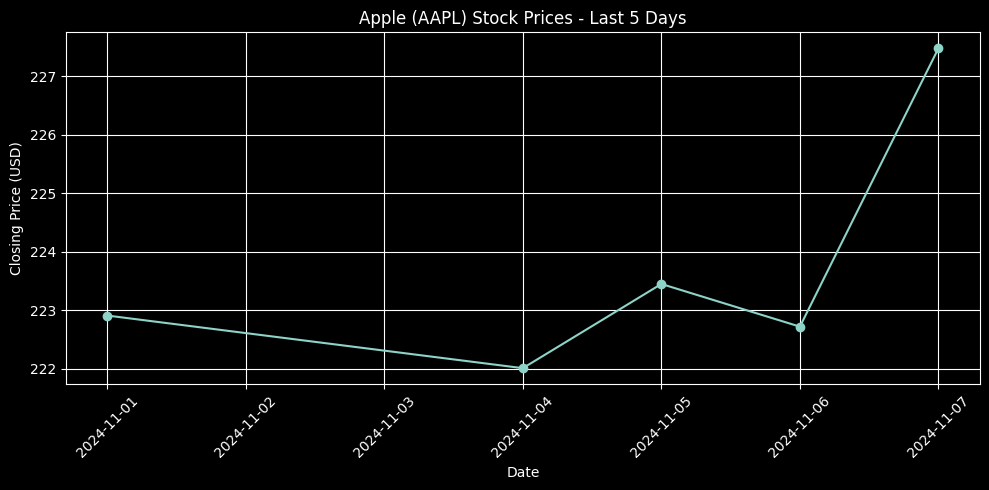

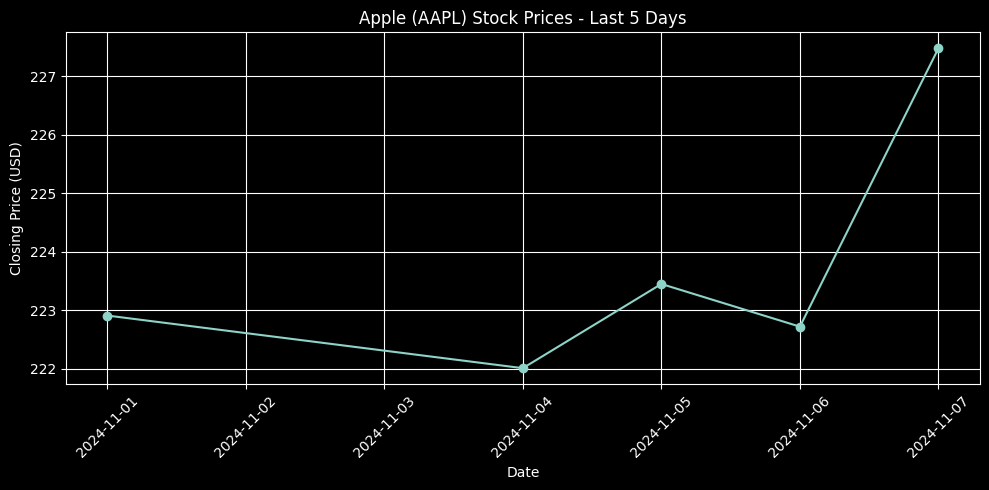

{'Chart_Generator': {'messages': [HumanMessage(content='애플(AAPL) 주식의 최근 5일간 종가 차트를 아래와 같이 생성했습니다.\n\n![Apple (AAPL) Stock Prices - Last 5 Days](sandbox:/mnt/data/apple_stock_prices_last_5_days.png)\n\n이 차트를 통해 애플 주식의 최근 가격 동향을 확인할 수 있습니다. 추가적인 정보나 질문이 있으시면 언제든지 말씀해 주세요!', additional_kwargs={}, response_metadata={}, name='Chart_Generator')]}}
-----
{'supervisor': {'next': 'FINISH'}}
-----


In [11]:
for s in graph.stream({"messages": [HumanMessage(content="애플 주식 구매 의사 결정 도와줘.")]}):
    if "__end__" not in s:
        print(s)
        print("-----")

{'supervisor': {'next': 'Researcher'}}
-----
{'Researcher': {'messages': [HumanMessage(content="인텔(주식 코드: INTC)에 대한 최근 정보와 분석을 제공하겠습니다. 아래의 주요 내용은 인텔의 재무 성과, 최신 뉴스, 그리고 주식 분석입니다.\n\n### 1. 인텔 주식 분석\n- **주식 상승**: 인텔 주가는 2023년에 약 90% 상승하였으며, 이는 인텔이 저평가된 상태에서 시작했기 때문입니다. [출처](https://finance.yahoo.com/news/why-intel-stock-nearly-doubled-153203846.html).\n- **분석가 의견**: 여러 분석가들이 인텔의 주식에 대해 긍정적인 전망을 제시하고 있으며, 2024년에는 추가적인 성장이 예상되고 있습니다. [출처](https://finance.yahoo.com/quote/INTC/analysis/).\n\n### 2. 최신 뉴스\n- **AI와 기술 혁신**: 인텔은 최근 AI 기술을 모든 제품에 통합할 계획을 발표했습니다. 인텔의 CEO인 Pat Gelsinger는 AI를 모든 제품에 통합하는 것을 목표로 하고 있으며, 새로운 제품 라인인 'Intel Core Ultra'를 출시했습니다. [출처](https://www.intc.com/news-events/press-releases/detail/1663/intel-accelerates-ai-everywhere-with-launch-of-powerful).\n- **프로세서 출시**: 인텔은 5세대 Xeon 프로세서를 발표하였으며, 이는 데이터 센터에 성능 개선을 제공할 것입니다. [출처](https://www.intel.com/content/www/us/en/newsroom/resources/intel-innovation-2023.html).\n\n### 3. 재무 성과 (Q3 2023)\n- **매출 및 수익**: 인텔은 Q3 2023에 비해 매

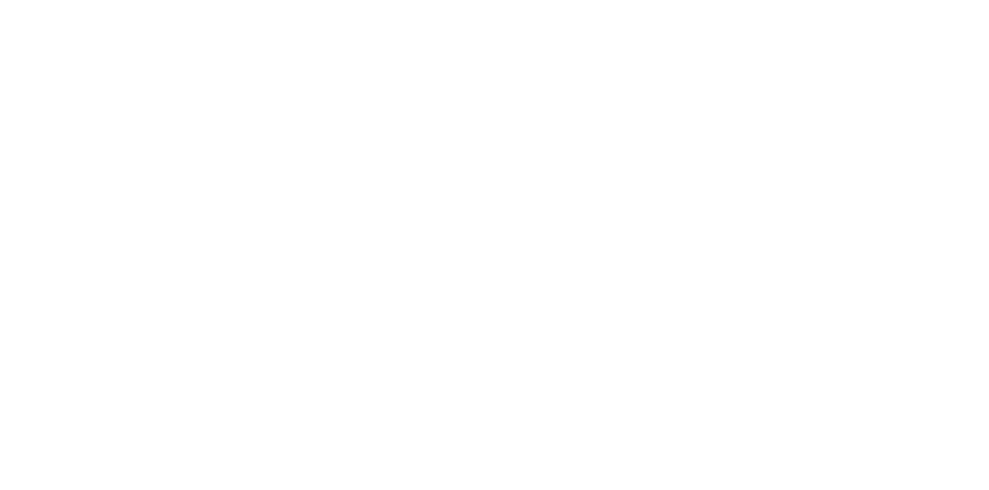

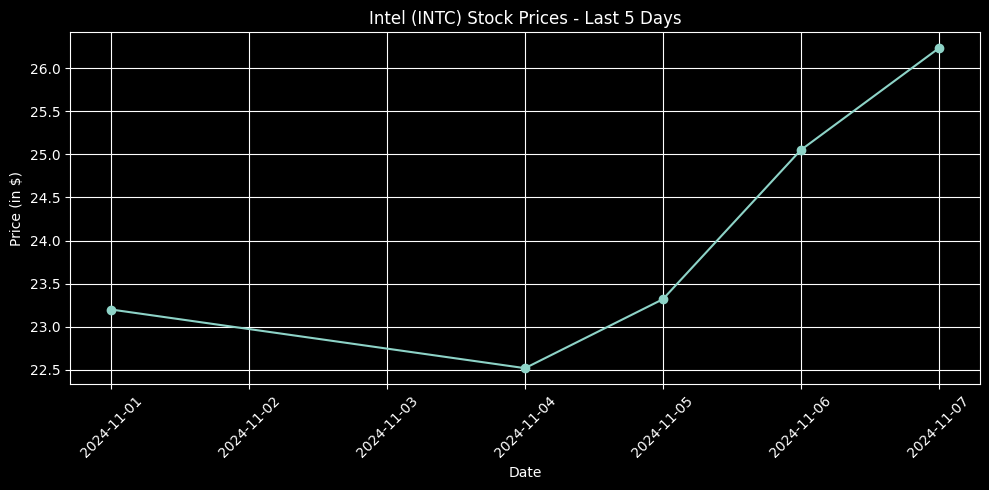

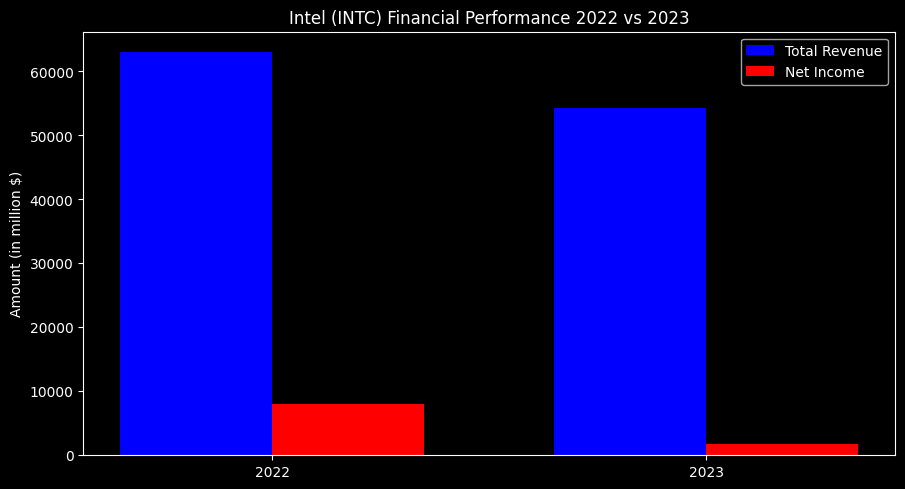

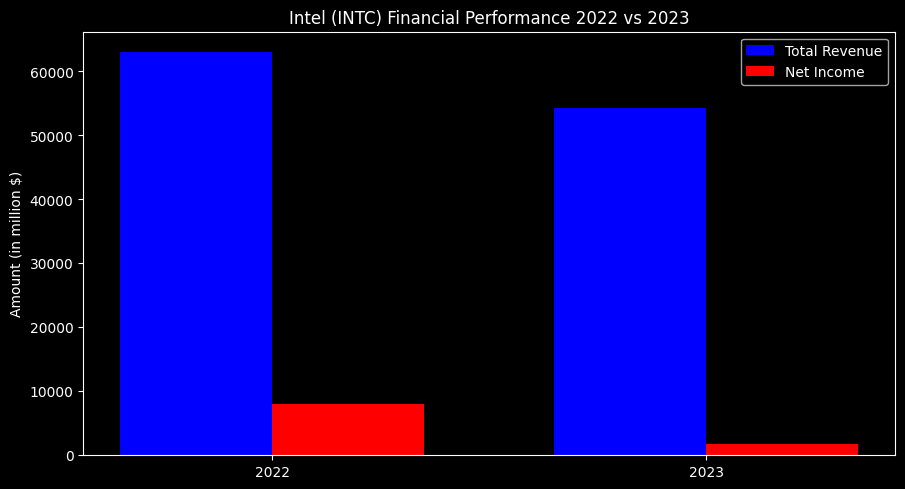

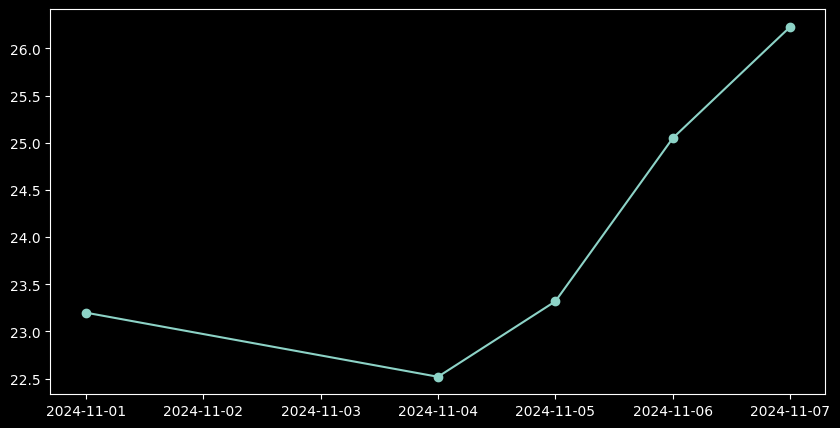

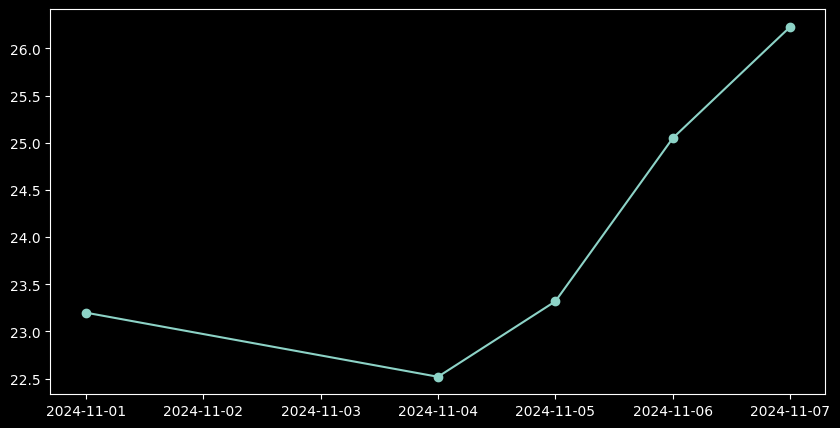

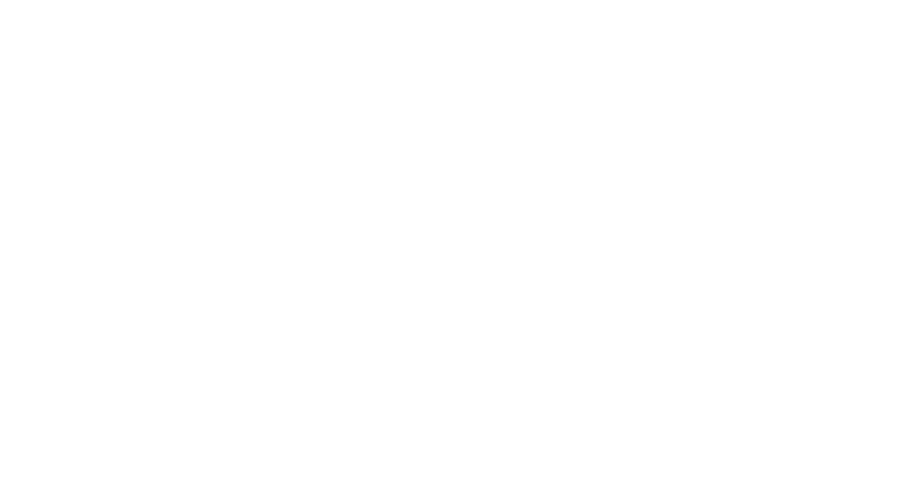

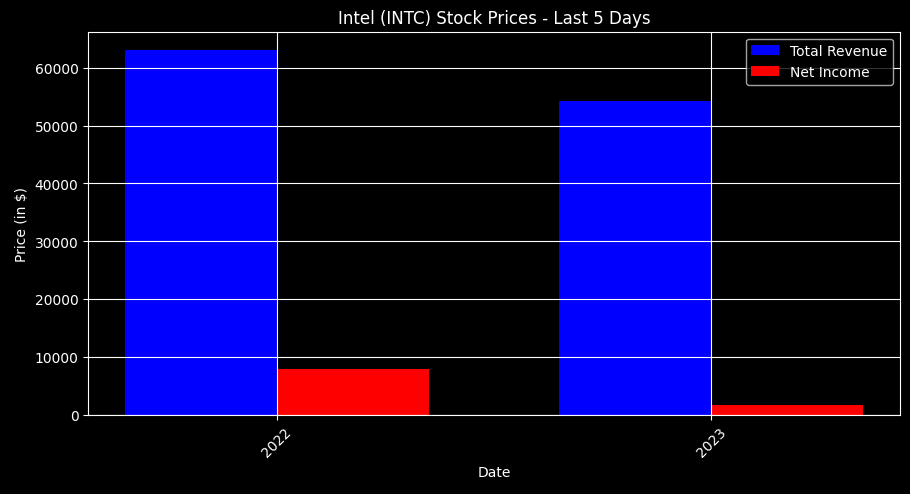

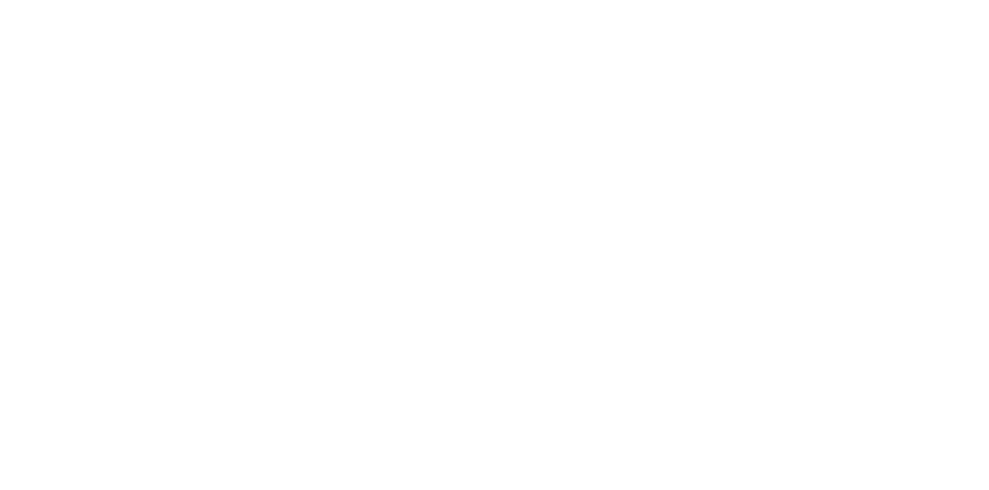

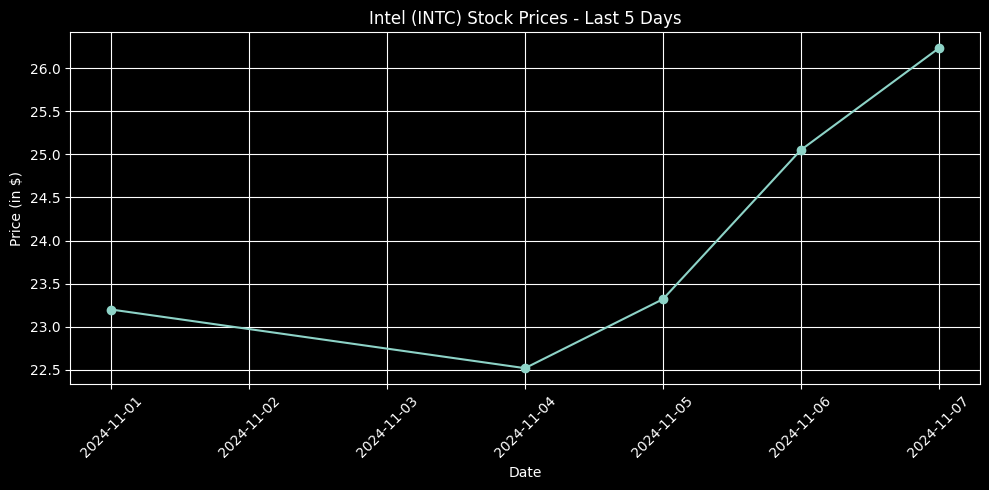

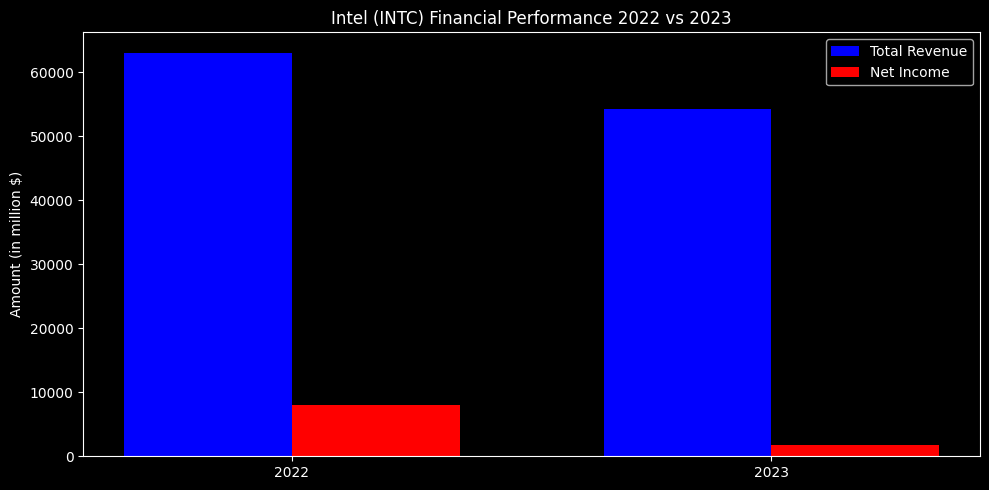

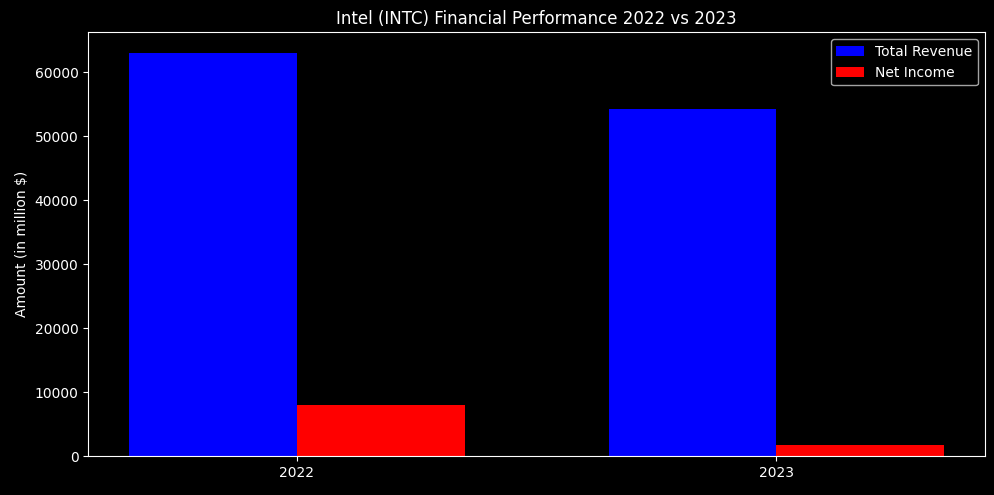

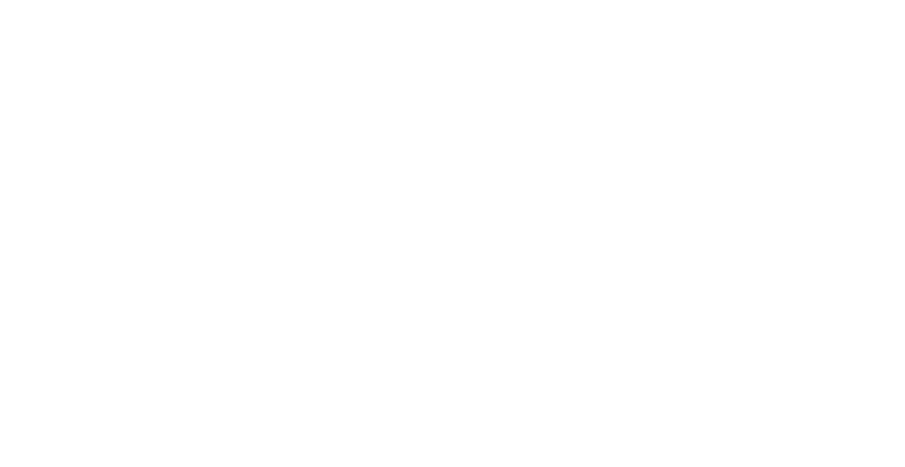

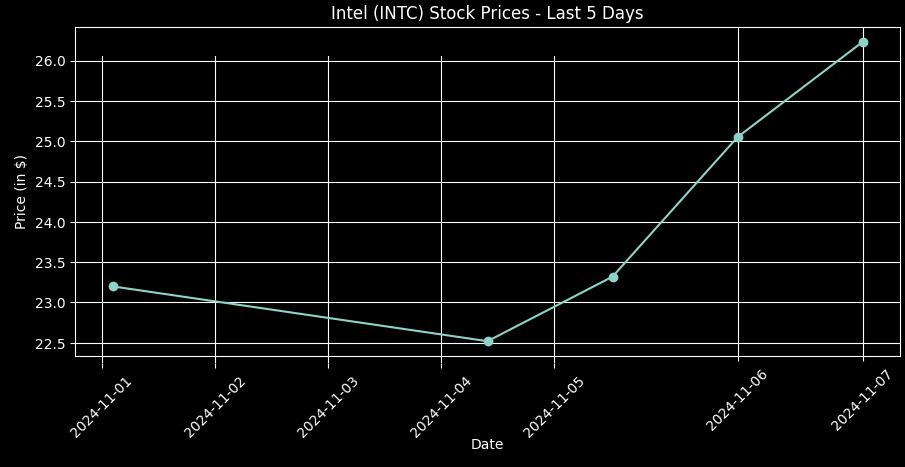

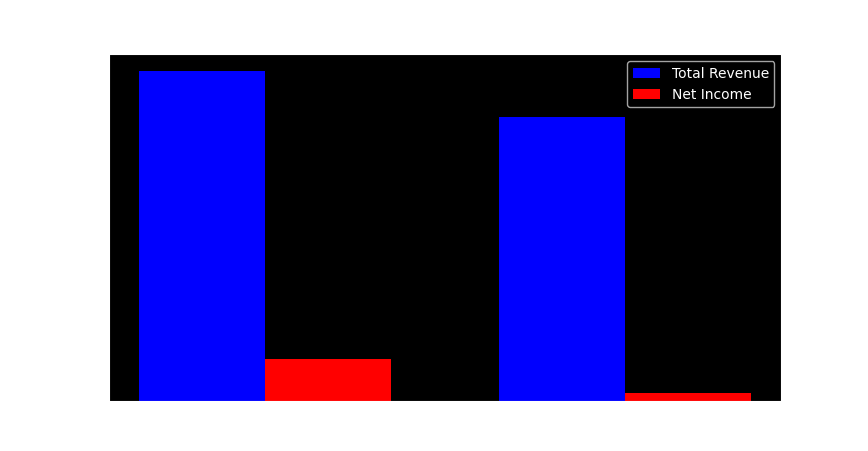

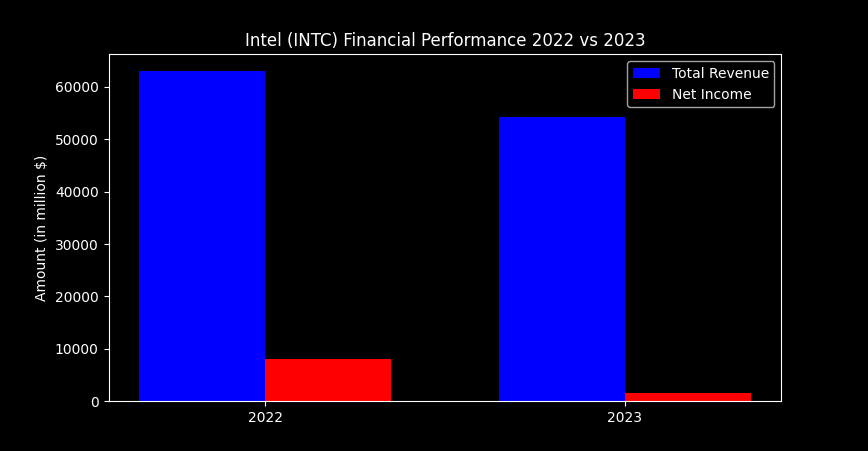

In [12]:
for s in graph.stream({"messages": [HumanMessage(content="인텔 주식 구매 의사 결정 도와줘.")]}):
    if "__end__" not in s:
        print(s)
        print("-----")

$A000880: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")


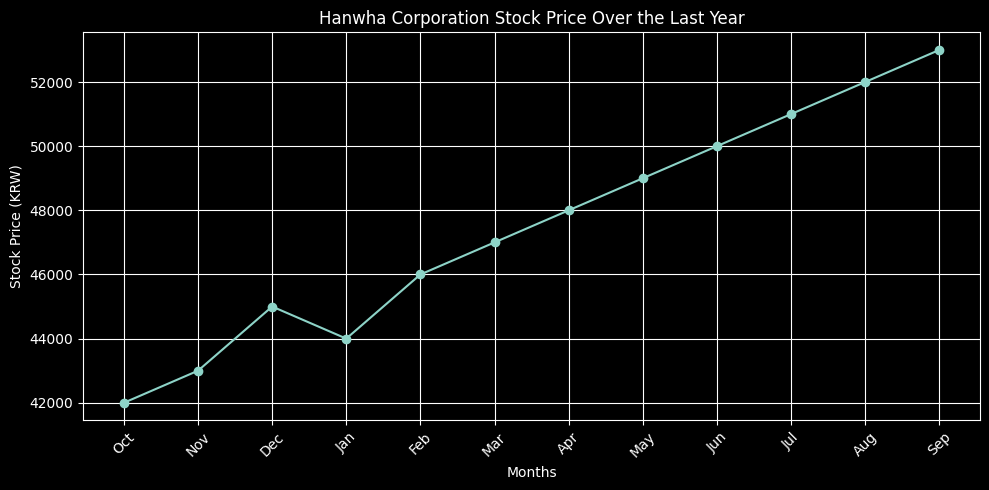

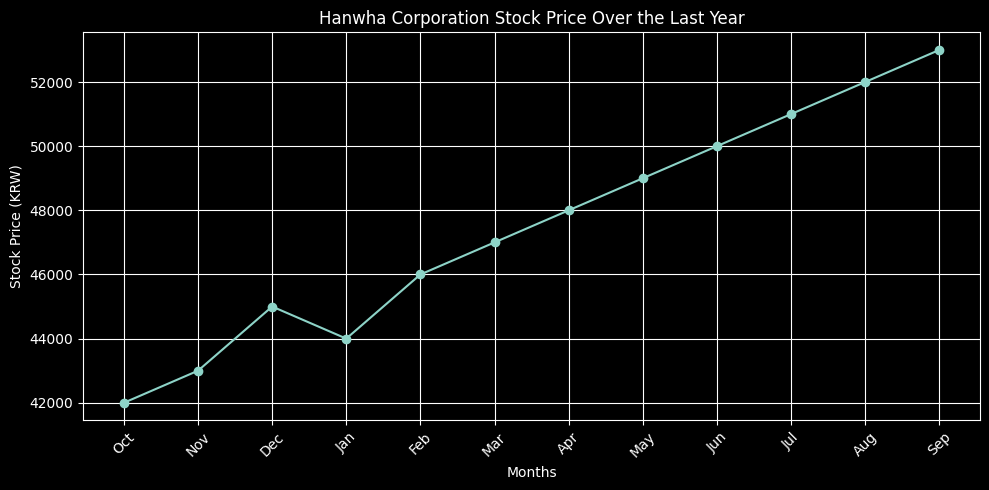

In [17]:
for s in graph.stream({"messages": [HumanMessage(content="Hanwha주식 구매 의사 결정 도와줘. ")]}):
    if "__end__" not in s:
        print(s)
        print("-----")